# 1 · Surface diffusion on a membrane

This notebook runs a single surface PDE **through the declarative formalism** —
not by hand-writing FEM code. We:

1. write the model as a `MathDescription` (YAML),
2. **validate** it structurally,
3. resolve a **geometry** and **assemble** it into a solvable problem,
4. step it in time and check the result against the analytical decay rate.

The model is pure surface diffusion of a density `rho` on a circular membrane:
∂ₜρ = D Δ_Γ ρ. A `cos(kθ)` mode on a circle of radius r decays as
`exp(-D k²/r² · t)`, which we verify.

In [1]:
from vcell_fenics.formalism import load_yaml, validate
from vcell_fenics.backend import assemble, make_disk_membrane_geometry
import numpy as np, math
import matplotlib.pyplot as plt

## The model

`geometry` is referenced by *name*; the model only declares the vocabulary it
uses (a `surface` subdomain `membrane`, a variable `rho`). The initial condition
is a `cos(2θ)` mode written in the formalism's expression language
(`theta(x)` is the polar-angle helper).

In [2]:
MODEL = """
math_description:
  geometry: disk_membrane
  subdomains:
    - { name: membrane, kind: surface, motion: { kind: none } }
  variables:
    - { name: rho, subdomain: membrane }
  equations:
    - template: surface_pde_with_dilution
      variable: rho
      subdomain: membrane
      temporality: time_dependent
      terms: { diffusion: "0.1" }
      initial_condition: "1.0 + 0.5 * cos(2 * theta(x))"
"""

md = load_yaml(MODEL)
errors = [d for d in validate(md) if d.severity == "error"]
print("validation errors:", errors or "none")

validation errors: none


## Geometry + assembly

The geometry resolves the `membrane` name to a concrete mesh (the boundary of a
disk). `assemble` validates, cross-checks against the geometry, and lowers the
model into a `DiscreteProblem`. We can inspect *what terms it built* — a static
membrane has no dilution term, just the time-derivative + diffusion.

In [3]:
geometry = make_disk_membrane_geometry("disk_membrane", surface_subdomain="membrane", radius=1.0, h=0.05)
dp = assemble(md, geometry, dt=0.01)
print("term kinds:", sorted(t.name for t in dp.term_kinds()))

term kinds: ['DIFFUSION', 'TIME_DERIVATIVE']


## Step in time, track the mode amplitude

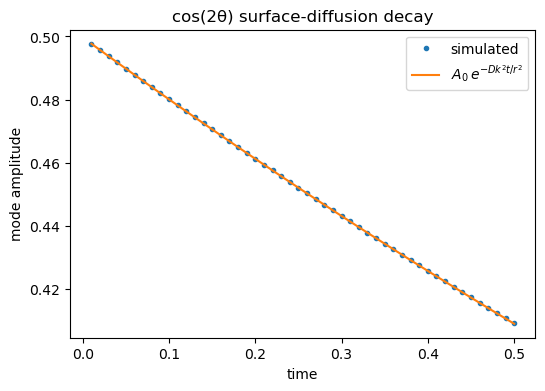

final amplitude: simulated 0.4092  vs  analytical 0.4091


In [4]:
amp0 = 0.5 * (dp.unknown.x.array.max() - dp.unknown.x.array.min())
times, amps = [], []
for i in range(50):
    dp.step()
    times.append((i + 1) * 0.01)
    amps.append(0.5 * (dp.unknown.x.array.max() - dp.unknown.x.array.min()))

D, k, r = 0.1, 2, 1.0
analytical = [amp0 * math.exp(-D * k**2 / r**2 * t) for t in times]

plt.figure(figsize=(6, 4))
plt.plot(times, amps, "o", ms=3, label="simulated")
plt.plot(times, analytical, "-", label=r"$A_0\,e^{-D k^2 t / r^2}$")
plt.xlabel("time"); plt.ylabel("mode amplitude"); plt.legend(); plt.title("cos(2θ) surface-diffusion decay")
plt.show()
print(f"final amplitude: simulated {amps[-1]:.4f}  vs  analytical {analytical[-1]:.4f}")

**Takeaway.** The simulated decay matches the analytical rate to backward-Euler
accuracy — and we never wrote a weak form. The same `MathDescription` would run
on any geometry that provides a `membrane` surface.